In [82]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [83]:
df = pd.read_csv(r"german_credit_data.csv")
df.drop(columns=["Unnamed: 0"], inplace=True)

In [84]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [85]:
df.shape

(1000, 10)

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB


In [87]:
df.describe()

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


In [88]:
df.isnull().sum()

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

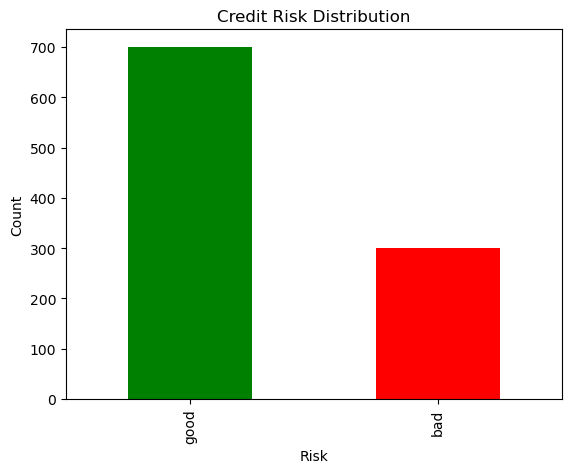

Risk
good    700
bad     300
Name: count, dtype: int64


In [89]:
import matplotlib.pyplot as plt

df["Risk"].value_counts().plot(
    kind="bar",
    color=["green", "red"]   # Different colors for both bars
)

plt.title("Credit Risk Distribution")
plt.xlabel("Risk")
plt.ylabel("Count")
plt.show()

print(df["Risk"].value_counts())

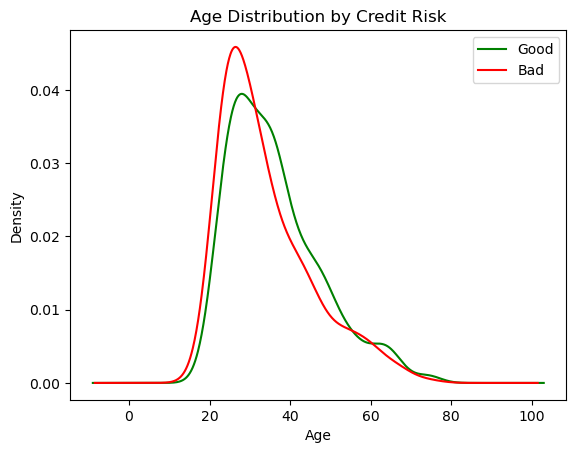

In [90]:
import matplotlib.pyplot as plt

df[df["Risk"] == "good"]["Age"].plot(kind="kde", color="green", label="Good")
df[df["Risk"] == "bad"]["Age"].plot(kind="kde", color="red", label="Bad")

plt.title("Age Distribution by Credit Risk")
plt.xlabel("Age")
plt.legend()
plt.show()

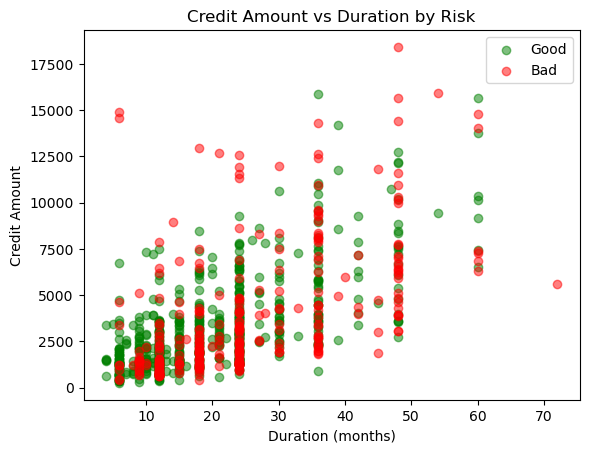

In [91]:
import matplotlib.pyplot as plt

good = df[df["Risk"] == "good"]
bad = df[df["Risk"] == "bad"]

plt.scatter(good["Duration"], good["Credit amount"], color="green", alpha=0.5, label="Good")
plt.scatter(bad["Duration"], bad["Credit amount"], color="red", alpha=0.5, label="Bad")

plt.title("Credit Amount vs Duration by Risk")
plt.xlabel("Duration (months)")
plt.ylabel("Credit Amount")
plt.legend()
plt.show()

In [92]:
# Fill missing values with mode
df['Saving accounts']=df['Saving accounts'].fillna(df['Saving accounts'].mode()[0])
df['Checking account']=df['Checking account'].fillna(df['Checking account'].mode()[0])
print("Missing values after fill:")
print(df.isnull().sum())

Missing values after fill:
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64


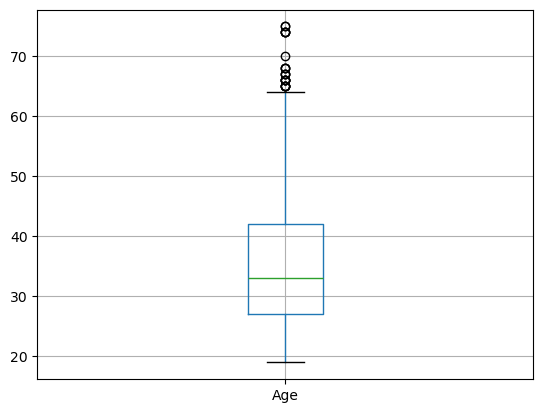

In [93]:
df.boxplot(column='Age')
plt.show()

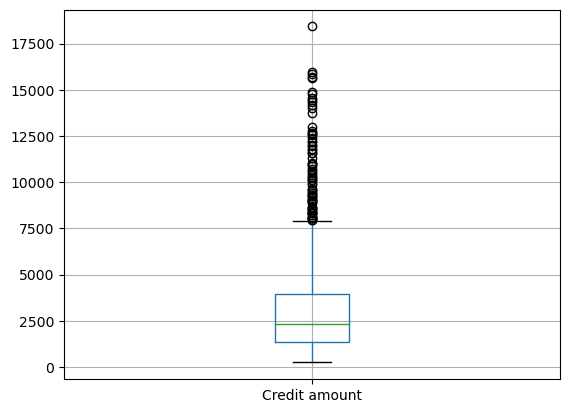

In [99]:
df.boxplot(column='Credit amount')
plt.show()

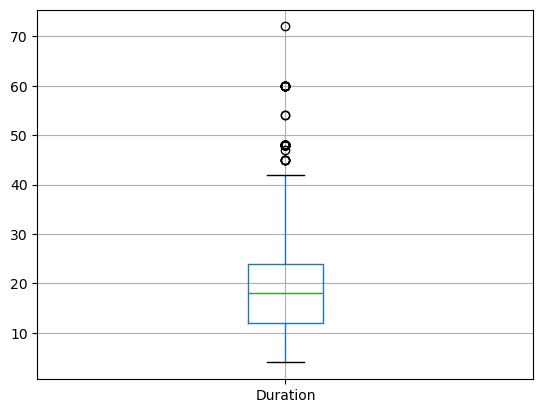

In [100]:
df.boxplot(column='Duration')
plt.show()

In [103]:
# Label Encoding for categorical columns
le=LabelEncoder()
for col in df.columns:
    if df[col].dtype=="object":
        df[col]=le.fit_transform(df[col])
        

In [104]:
# Outlier Removal using IQR (only for numeric columns)
numeric_cols = ['Age', 'Credit amount', 'Duration']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Rows after removing outliers:", len(df))

Rows after removing outliers: 861


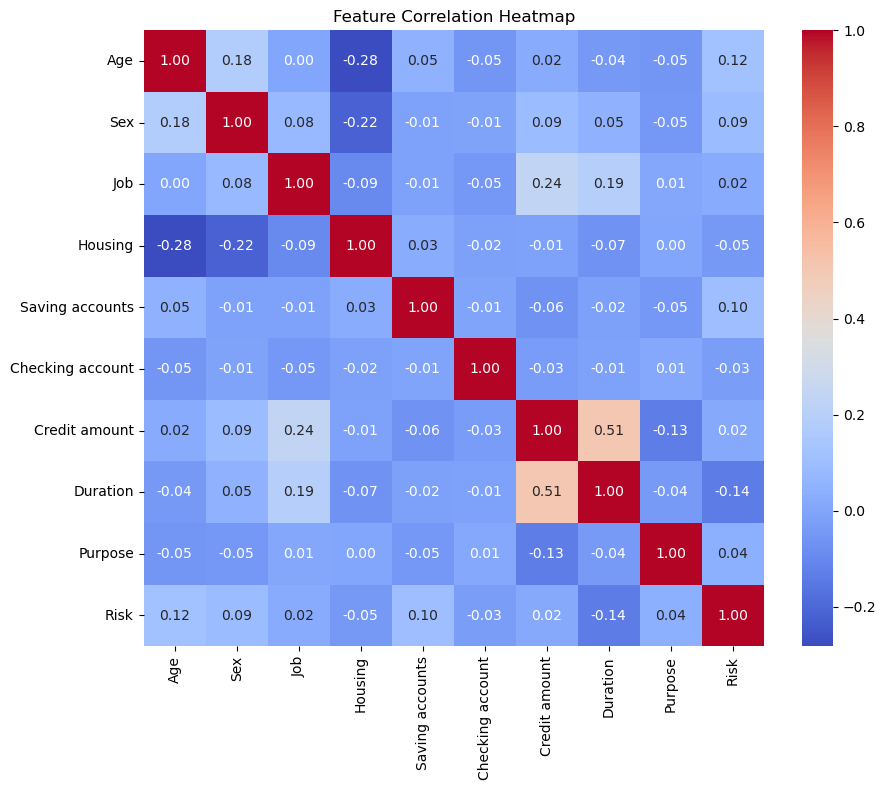

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [106]:
X = df.drop("Risk", axis=1)

y = df["Risk"]

In [107]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [108]:
print(X_train.shape)
print(X_test.shape)

(688, 9)
(173, 9)


In [109]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [110]:
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(class_weight="balanced", max_depth=6, random_state=42),
    "Random Forest":       RandomForestClassifier(class_weight="balanced", n_estimators=300, max_depth=10, random_state=42)
}

results = {}

for name, m in models.items():
    # Use scaled data for LR, unscaled for trees (both work; scaled is safe for all)
    m.fit(X_train_sc, y_train)
    y_pred = m.predict(X_test_sc)
    y_prob = m.predict_proba(X_test_sc)[:, 1]

    acc   = accuracy_score(y_test, y_pred)
    roc   = roc_auc_score(y_test, y_prob)
    cv    = cross_val_score(m, X_train_sc, y_train, cv=5, scoring="accuracy").mean()

    results[name] = {"Accuracy": round(acc, 4), "ROC-AUC": round(roc, 4), "CV Accuracy": round(cv, 4)}
    print(f"{'='*40}")
    print(f"Model: {name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"ROC-AUC  : {roc:.4f}")
    print(f"5-Fold CV: {cv:.4f}")
    print(classification_report(y_test, y_pred, target_names=["bad", "good"]))

Model: Logistic Regression
Accuracy : 0.6185
ROC-AUC  : 0.6753
5-Fold CV: 0.5887
              precision    recall  f1-score   support

         bad       0.37      0.63      0.47        46
        good       0.82      0.61      0.70       127

    accuracy                           0.62       173
   macro avg       0.60      0.62      0.59       173
weighted avg       0.70      0.62      0.64       173

Model: Decision Tree
Accuracy : 0.5549
ROC-AUC  : 0.5861
5-Fold CV: 0.5394
              precision    recall  f1-score   support

         bad       0.33      0.65      0.44        46
        good       0.80      0.52      0.63       127

    accuracy                           0.55       173
   macro avg       0.57      0.59      0.53       173
weighted avg       0.68      0.55      0.58       173

Model: Random Forest
Accuracy : 0.6936
ROC-AUC  : 0.6426
5-Fold CV: 0.7238
              precision    recall  f1-score   support

         bad       0.39      0.26      0.31        46
      

In [111]:
# Use Random Forest as the best model
best_model = models["Random Forest"]
y_pred_best = best_model.predict(X_test_sc)
y_prob_best = best_model.predict_proba(X_test_sc)[:, 1]

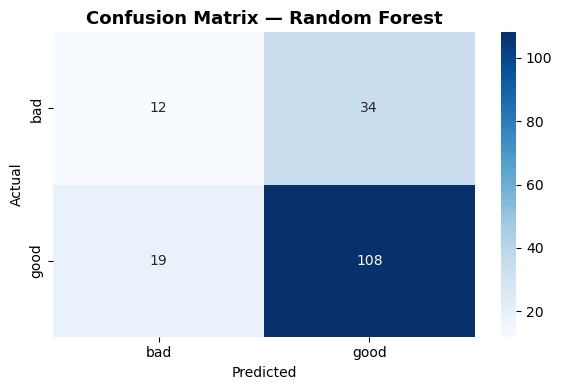

In [112]:
# Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["bad", "good"], yticklabels=["bad", "good"])
plt.title("Confusion Matrix — Random Forest", fontsize=13, fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

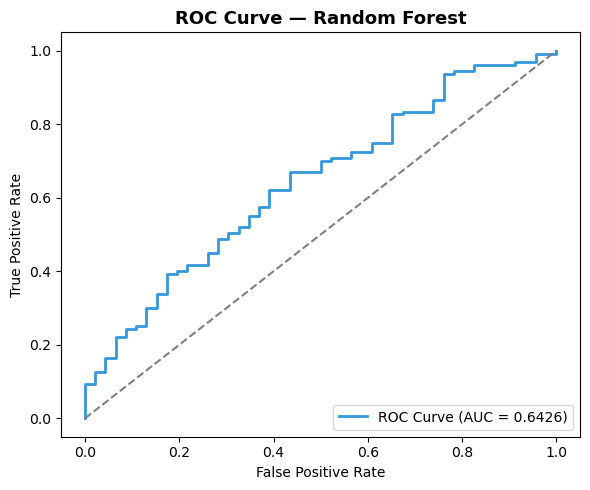

In [113]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
auc_score   = roc_auc_score(y_test, y_prob_best)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="#3498db", lw=2, label=f"ROC Curve (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.title("ROC Curve — Random Forest", fontsize=13, fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

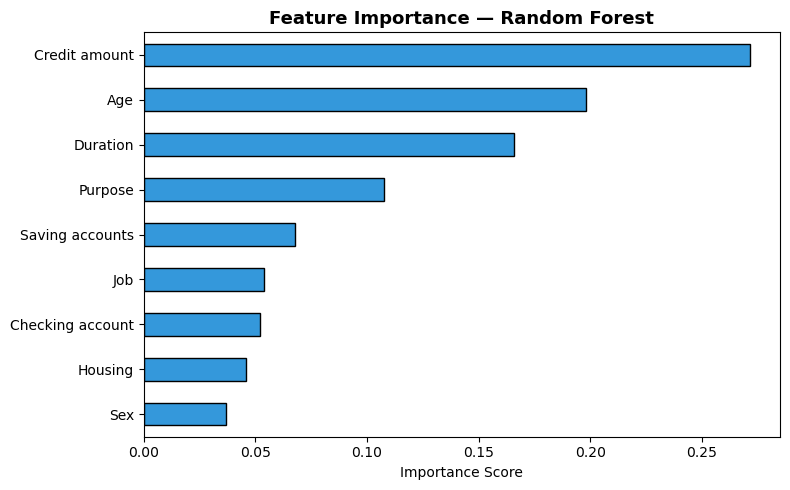

In [114]:
feat_imp = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feat_imp.plot(kind="barh", color="#3498db", edgecolor="black")
plt.title("Feature Importance — Random Forest", fontsize=13, fontweight="bold")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()